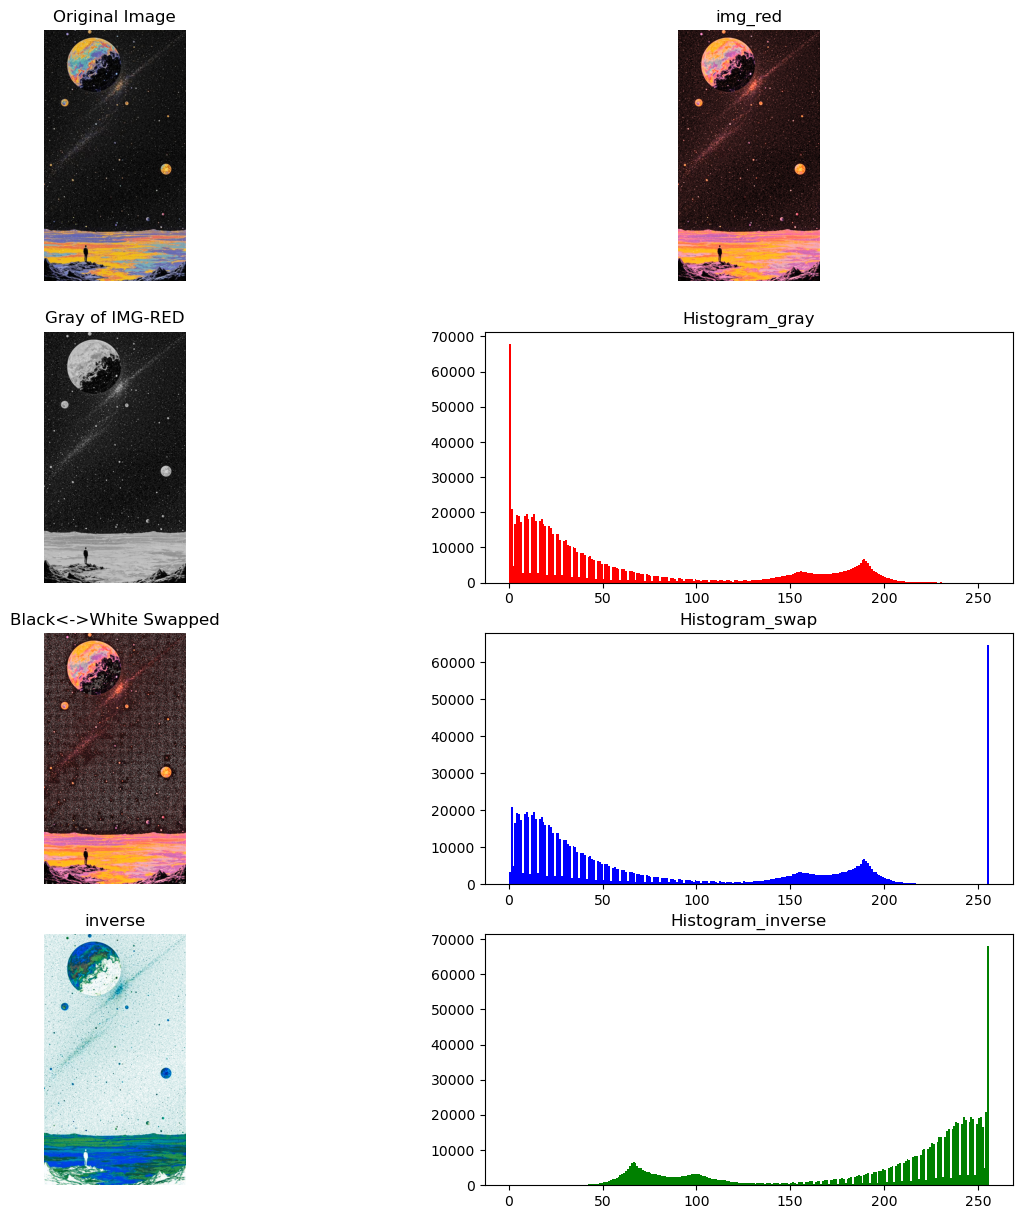

In [5]:
#  فراخوانی کتابخانه
import cv2
import matplotlib.pyplot as plt
# تعریف کلاس 
class picture() :     
    # تعریف تابع اولیه  و سازنده 
    def __init__(self , path) : 
        self.path = path 
        self.img = cv2.imread(self.path)
        self.img_rgb = cv2.cvtColor(self.img, cv2.COLOR_BGR2RGB)
        self.img_gray = cv2.cvtColor(self.img, cv2.COLOR_BGR2GRAY)
        self.fig = plt.figure(figsize=(15,15))
   
    # اجرای سطر اول (خود تصویر و تصویر قرمز)
    def satr1 (self) : 
        # نمایش خود تصویر 
        plt.subplot(4 , 2 , 1)
        plt.imshow(self.img_rgb)
        plt.title("Original Image")
        plt.axis('off')
        # استخراچ کانال قرمز و دو برابر کردن مقدار پیکسل ها (در صورتی که از 255 بیشتر شد همان 255)
        red_channel = self.img_rgb[:, :, 0]
        double = cv2.multiply(red_channel , 2)
        double[double > 255] = 255
        self.img_rgb[:, :, 0] = double
        plt.subplot(4 , 2 , 2)
        plt.imshow(self.img_rgb)  
        plt.title("img_red")
        plt.axis('off')
    # اجرای سطر دوم (خاکستری تصویر قرمز و هیستوگرام آن) 
    def satr2 (self) : 
        double_gray = cv2.cvtColor(self.img_rgb, cv2.COLOR_RGB2GRAY) # خاکستری کردن 
        plt.subplot(4 , 2 , 3)
        plt.imshow(double_gray, cmap='gray')
        plt.title("Gray of IMG-RED")
        plt.axis('off')
        plt.subplot(4 , 2 , 4) # هیستوگرام 
        plt.hist(double_gray.ravel(), bins=256, range=(0, 256), color='red')
        plt.title("Histogram_gray")

    def satr3 (self) : 
        # جابجایی رنگ های سفید و سیاه
        imgtest = self.img_rgb.copy()
        black_pixels = (imgtest[:,:,0] == 0) & (imgtest[:,:,1] == 0) & (imgtest[:,:,2] == 0)
        white_pixels = (imgtest[:,:,0] == 255) & (imgtest[:,:,1] == 255) & (imgtest[:,:,2] == 255)
        imgtest[black_pixels] = [255, 255, 255]
        imgtest[white_pixels] = [0, 0, 0]
        
        imgtest_gray = cv2.cvtColor(imgtest, cv2.COLOR_RGB2GRAY)
       
        # رسم تصویر 
        plt.subplot(4 , 2 , 5)
        plt.imshow(imgtest)
        plt.title("Black<->White Swapped")
        plt.axis('off')
        # رسم هیستوگرام
        plt.subplot(4 , 2 , 6)
        plt.hist(imgtest_gray.ravel(), bins=256, range=(0, 256), color='blue')
        plt.title("Histogram_swap")
   
    # اجرای سطر 4 (معکوس کردن شدت روشنایی عکس سطر دو و رسم هیستوگرام)
    def satr4 (self) :
        imgtest2 = 255 - self.img_rgb
        plt.subplot(4 , 2 , 7)
        plt.imshow(imgtest2) # رسم عکس
        plt.title("inverse")
        plt.axis('off')
        imgtest2_gray = cv2.cvtColor(imgtest2, cv2.COLOR_RGB2GRAY)
        
        plt.subplot(4 , 2 , 8)
        plt.hist(imgtest2_gray.ravel(), bins=256, range=(0, 256), color='green') # رسم هیستوگرام 
        plt.title("Histogram_inverse")

my_pic = picture(r"C:\Users\PISHRORAYANEH\Downloads\test_imp.jpg")

my_pic.satr1()
my_pic.satr2()
my_pic.satr3()
my_pic.satr4()

plt.show()